# Composite FamaFrench + AllWeather — Factor-Hedged Strategy Research

> **Strategy #44** | [RL-1 Q-Learning](research_rl_tabular.ipynb) · [RL-2 PPO](research_rl_ppo.ipynb) · [RL-3 Reward Shaping](research_rl_reward_shaping.ipynb) · [RL-4 Multi-Asset](research_rl_multi_asset.ipynb) · [RL-5 Overlay](research_rl_tactical_overlay.ipynb) · [RL-6 GRPO](research_rl_grpo.ipynb) · **Composite FF+AW**

## Objectifs
- Combiner **FamaFrench factor rotation** (VLUE/MTUM/SIZE/QUAL/USMV) avec le socle defensif **AllWeather** (SPY/IEF/GLD/XLP)
- Architecture inspiree de `Framework_Composite_TrendWeather` (Sharpe 1.155)
- Signal FamaFrench : momentum risque-ajuste (return 252d / vol 63d) avec skip-month
- Signal AllWeather : allocation statique 30/30/30/10
- Sweep allocation FF50-AW50 a FF80-AW20
- Walk-forward 5-fold, 4 seeds (0/1/7/42), verdict honnete

## Architecture
| Composant | Allocation | Signal |
|-----------|------------|--------|
| FamaFrench | 50-80% | Rotation trimestrielle, top-2 facteurs par momentum risque-ajuste |
| AllWeather | 20-50% | Allocation statique SPY 30% / IEF 30% / GLD 30% / XLP 10% |

**Cible** : Sharpe > 0.7 sur 2015-2025. Baseline = SPY B&H.

**Duree estimee** : ~2 min | **Prerequis** : pandas, numpy, panier data

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RESEARCH_DIR = Path(".")
DATASET_DIR = RESEARCH_DIR.parent / "datasets" / "panier"
SEEDS = [0, 1, 7, 42]
N_SPLITS = 5
FEE_BPS = 5  # transaction cost

# Factor ETFs (iShares Fama-French)
FF_TICKERS = ["VLUE", "MTUM", "SIZE", "QUAL", "USMV"]
# AllWeather defensive base
AW_TICKERS = ["SPY", "IEF", "GLD", "XLP"]
AW_WEIGHTS = {"SPY": 0.30, "IEF": 0.30, "GLD": 0.30, "XLP": 0.10}

print(f"FamaFrench factors: {FF_TICKERS}")
print(f"AllWeather: {AW_TICKERS} with weights {AW_WEIGHTS}")

FamaFrench factors: ['VLUE', 'MTUM', 'SIZE', 'QUAL', 'USMV']
AllWeather: ['SPY', 'IEF', 'GLD', 'XLP'] with weights {'SPY': 0.3, 'IEF': 0.3, 'GLD': 0.3, 'XLP': 0.1}


## 1. Chargement des donnees

On charge les prix depuis le panier CSV. Si indisponible, on telecharge via yfinance.

In [2]:
def load_prices(tickers):
    """Load daily close prices for given tickers. Try panier CSV first, then yfinance."""
    panier_path = DATASET_DIR / "panier_close_all.csv"
    all_tickers = list(set(tickers))
    
    prices = {}
    if panier_path.exists():
        df = pd.read_csv(panier_path, index_col=0, parse_dates=True)
        for t in all_tickers:
            if t in df.columns:
                prices[t] = df[t].dropna()
                print(f"  {t}: loaded from panier ({len(prices[t])} days)")
    
    missing = [t for t in all_tickers if t not in prices]
    if missing:
        try:
            import yfinance as yf
            data = yf.download(missing, start="2010-01-01", end="2026-05-01", auto_adjust=True)["Close"]
            if len(missing) == 1:
                data = data.to_frame(missing[0])
            for t in missing:
                prices[t] = data[t].dropna()
                print(f"  {t}: loaded from yfinance ({len(prices[t])} days)")
        except Exception as e:
            print(f"  yfinance unavailable: {e}")
            for t in missing:
                prices[t] = pd.Series(dtype=float)
    
    # Align to common index
    price_df = pd.DataFrame(prices)
    price_df.index = pd.DatetimeIndex(price_df.index)
    price_df = price_df.sort_index().ffill().dropna()
    print(f"\nCombined: {price_df.shape[1]} tickers, {price_df.shape[0]} days [{price_df.index.min().date()} .. {price_df.index.max().date()}]")
    return price_df

all_tickers = list(set(FF_TICKERS + AW_TICKERS))
prices = load_prices(all_tickers)
prices.head()

[                       0%                       ]

[***********           22%                       ]  2 of 9 completed

[****************      33%                       ]  3 of 9 completed

[********************* 44%                       ]  4 of 9 completed

[**********************56%**                     ]  5 of 9 completed

[**********************67%*******                ]  6 of 9 completed

[**********************89%******************     ]  8 of 9 completed

[*********************100%***********************]  9 of 9 completed

  MTUM: loaded from yfinance (3279 days)
  SIZE: loaded from yfinance (3279 days)
  VLUE: loaded from yfinance (3279 days)
  SPY: loaded from yfinance (4106 days)
  XLP: loaded from yfinance (4106 days)
  USMV: loaded from yfinance (3652 days)
  QUAL: loaded from yfinance (3216 days)
  GLD: loaded from yfinance (4106 days)
  IEF: loaded from yfinance (4106 days)

Combined: 9 tickers, 3216 days [2013-07-18 .. 2026-04-30]


,MTUM,SIZE,VLUE,SPY,XLP,USMV,QUAL,GLD,IEF
Date,,,,,,,,,
2013-07-18,46.555901,42.814312,40.159485,135.765396,29.641876,26.586594,41.669071,124.010002,77.126450
2013-07-19,46.762398,42.814312,40.086102,136.006668,29.813057,26.649435,41.345032,125.110001,77.549072
2013-07-22,46.822620,43.589218,40.196163,136.271988,29.748861,26.657288,41.544426,128.839996,77.541534
2013-07-23,46.745186,43.589218,40.196163,135.982498,29.691809,26.625875,41.477974,129.710007,77.450989
2013-07-24,46.581703,43.589218,40.196163,135.484024,29.499235,26.453085,41.419800,127.480003,76.930191


## 2. Signaux FamaFrench et AllWeather

**FamaFrench** : momentum risque-ajuste (252d return / 63d vol) avec skip-month (evite le biais de reversal a 1 mois). Filtre regime via SPY > SMA200.

**AllWeather** : allocation statique 30/30/30/10 rebalancee mensuellement.

In [3]:
def compute_ff_signals(prices, ff_tickers=FF_TICKERS, lookback=252, skip_days=21, vol_window=63):
    """Compute FamaFrench risk-adjusted momentum signals.
    
    Returns DataFrame of risk-adjusted momentum scores per factor per day.
    Signal = (252d-21d return) / (63d annualized vol).
    """
    signals = pd.DataFrame(index=prices.index, columns=ff_tickers, dtype=float)
    
    for t in ff_tickers:
        if t not in prices.columns:
            continue
        close = prices[t]
        ret_252 = close / close.shift(lookback) - 1  # 12m return
        ret_skip = close.shift(skip_days) / close.shift(lookback) - 1  # skip-month return
        vol_63 = close.pct_change().rolling(vol_window, min_periods=vol_window).std() * np.sqrt(252)
        
        # Risk-adjusted momentum (momentum Sharpe)
        risk_adj = ret_skip / vol_63.replace(0, np.nan)
        signals[t] = risk_adj
    
    return signals


def compute_spy_regime(prices, sma_period=200):
    """SPY > SMA200 regime filter."""
    if "SPY" not in prices.columns:
        return pd.Series(True, index=prices.index)
    spy_close = prices["SPY"]
    sma = spy_close.rolling(sma_period, min_periods=sma_period).mean()
    return spy_close > sma


ff_signals = compute_ff_signals(prices)
regime = compute_spy_regime(prices)

print(f"FF signals shape: {ff_signals.shape}")
print(f"Regime: {regime.sum()}/{len(regime)} days risk-on ({regime.mean()*100:.1f}%)")
print(f"\nFF signal stats (last available date):")
last_signals = ff_signals.dropna(how='all').iloc[-1]
print(last_signals.to_string())

FF signals shape: (3216, 5)
Regime: 2509/3216 days risk-on (78.0%)

FF signal stats (last available date):
VLUE    2.191348
MTUM    0.600456
SIZE    0.884476
QUAL    0.935231
USMV    0.271810


## 3. Strategie composite avec walk-forward

On combine FamaFrench (top-N facteurs par momentum risque-ajuste) + AllWeather (allocation statique).
Walk-forward 5-fold expanding avec bornee, 4 seeds.

In [4]:
def walk_forward_composite(prices, ff_alloc, top_n=2, seed=0):
    """Walk-forward validation for FF+AW composite.
    
    ff_alloc: fraction allocated to FamaFrench (0.5 to 0.8)
    aw_alloc: 1 - ff_alloc goes to AllWeather
    top_n: number of top factors to hold in FF sleeve
    
    Returns dict with Sharpe, CAGR, max DD, and per-fold details.
    """
    np.random.seed(seed)
    aw_alloc = 1.0 - ff_alloc
    
    ff_signals = compute_ff_signals(prices)
    regime = compute_spy_regime(prices)
    
    # Daily returns
    returns = prices.pct_change().shift(-1)  # next-day return
    
    n = len(prices)
    fold_size = n // (N_SPLITS + 1)
    if fold_size < 300:
        return None
    
    all_dates = []
    all_port_ret = []
    all_bh_ret = []
    
    for k in range(1, N_SPLITS + 1):
        tr_end = fold_size * k
        te_end = min(tr_end + fold_size, n)
        tr_start = max(0, tr_end - 1500)  # bounded train window
        
        if te_end - tr_end < 60:
            continue
        
        # Out-of-test period
        for i in range(tr_end, te_end):
            date = prices.index[i]
            sig_row = ff_signals.iloc[i] if i < len(ff_signals) else None
            is_risk_on = regime.iloc[i] if i < len(regime) else True
            
            if sig_row is None or sig_row.isna().all():
                continue
            
            # --- FF sleeve: select top_n factors by risk-adjusted momentum ---
            ff_weights = {}
            if is_risk_on:
                sorted_factors = sig_row.dropna().sort_values(ascending=False)
                positive = sorted_factors[sorted_factors > 0]
                selected = positive.head(top_n).index.tolist()
                
                if not selected:
                    selected = ["USMV"]  # defensive fallback
                
                ff_w = ff_alloc / len(selected)
                for t in selected:
                    ff_weights[t] = ff_w
            else:
                # Risk-off: FF sleeve goes to USMV
                ff_weights["USMV"] = ff_alloc
            
            # --- AW sleeve: static allocation ---
            aw_weights = {}
            for t, w in AW_WEIGHTS.items():
                aw_weights[t] = w * aw_alloc
            
            # --- Combine ---
            combined = {}
            for t, w in ff_weights.items():
                combined[t] = combined.get(t, 0) + w
            for t, w in aw_weights.items():
                combined[t] = combined.get(t, 0) + w
            
            # Compute portfolio return (next day)
            if i + 1 < len(returns):
                port_ret = 0.0
                for t, w in combined.items():
                    if t in returns.columns and not np.isnan(returns.iloc[i + 1].get(t, np.nan)):
                        port_ret += w * returns.iloc[i + 1].get(t, 0)
                all_port_ret.append(port_ret)
                all_dates.append(date)
                # BH = equal weight all tickers
                bh_ret = returns.iloc[i + 1][[t for t in combined if t in returns.columns]].mean()
                all_bh_ret.append(bh_ret if not np.isnan(bh_ret) else 0)
    
    if len(all_port_ret) < 100:
        return None
    
    port_ret = np.array(all_port_ret)
    bh_ret = np.array(all_bh_ret)
    
    # Apply transaction costs (approx: penalize turnover)
    # Simple approximation: monthly rebalance ~0.5% round-trip per month
    monthly_tc = (FEE_BPS / 10000) * 2  # round-trip
    port_ret_net = port_ret - monthly_tc / 21  # amortized daily
    
    def sharpe(r):
        if len(r) < 30 or np.std(r, ddof=1) < 1e-12:
            return np.nan
        return float(np.mean(r) / np.std(r, ddof=1) * np.sqrt(252))
    
    def max_dd(r):
        cum = np.cumprod(1 + r)
        peak = np.maximum.accumulate(cum)
        dd = (cum - peak) / peak
        return float(dd.min())
    
    def cagr(r):
        cum = np.prod(1 + r)
        years = len(r) / 252
        return float(cum ** (1 / years) - 1) if years > 0 and cum > 0 else np.nan
    
    # SPY B&H baseline
    spy_ret = returns["SPY"].dropna().values if "SPY" in returns.columns else np.array([])
    spy_sharpe = sharpe(spy_ret) if len(spy_ret) >= 100 else np.nan
    
    return {
        "sharpe_gross": sharpe(port_ret),
        "sharpe_net": sharpe(port_ret_net),
        "sharpe_bh": sharpe(bh_ret),
        "sharpe_spy": spy_sharpe,
        "cagr_gross": cagr(port_ret),
        "cagr_net": cagr(port_ret_net),
        "max_dd_gross": max_dd(port_ret),
        "max_dd_net": max_dd(port_ret_net),
        "n_obs": len(port_ret),
        "ff_alloc": ff_alloc,
        "top_n": top_n,
        "seed": seed,
    }


# Quick test
test = walk_forward_composite(prices, ff_alloc=0.6, top_n=2, seed=0)
if test:
    print(f"Quick test (FF60/AW40, top=2): Sharpe gross={test['sharpe_gross']:.3f}, net={test['sharpe_net']:.3f}, SPY={test['sharpe_spy']:.3f}")
else:
    print("Quick test: insufficient data")

Quick test (FF60/AW40, top=2): Sharpe gross=0.997, net=0.901, SPY=0.852


## 4. Sweep allocation FF/AW + top_n

Sweep: FF allocation (50/60/70/80%) x top_n (1/2/3) x 4 seeds. Verdict honnete BEATS/NO BEATS/INCONCLUSIVE.

In [5]:
from itertools import product

FF_ALLOCS = [0.5, 0.6, 0.7, 0.8]
TOP_N_VALUES = [1, 2, 3]
EDGE_SIGMA = 2.0

rows = []
total = len(FF_ALLOCS) * len(TOP_N_VALUES) * len(SEEDS)
n = 0

for ff_alloc, top_n, seed in product(FF_ALLOCS, TOP_N_VALUES, SEEDS):
    n += 1
    result = walk_forward_composite(prices, ff_alloc=ff_alloc, top_n=top_n, seed=seed)
    if result is None:
        print(f"[{n}/{total}] FF{ff_alloc:.0%}/top={top_n}/seed={seed} SKIP")
        continue
    rows.append(result)
    print(f"[{n}/{total}] FF{ff_alloc:.0%}/top={top_n}/seed={seed} "
          f"Sharpe net={result['sharpe_net']:.3f} SPY={result['sharpe_spy']:.3f} "
          f"CAGR={result['cagr_net']:.3f}")

print(f"\nTotal: {len(rows)} combos completed")

[1/48] FF50%/top=1/seed=0 Sharpe net=0.957 SPY=0.852 CAGR=0.112


[2/48] FF50%/top=1/seed=1 Sharpe net=0.957 SPY=0.852 CAGR=0.112


[3/48] FF50%/top=1/seed=7 Sharpe net=0.957 SPY=0.852 CAGR=0.112


[4/48] FF50%/top=1/seed=42 Sharpe net=0.957 SPY=0.852 CAGR=0.112


[5/48] FF50%/top=2/seed=0 Sharpe net=0.933 SPY=0.852 CAGR=0.107


...

[44/48] FF80%/top=2/seed=42 Sharpe net=0.840 SPY=0.852 CAGR=0.116


[45/48] FF80%/top=3/seed=0 Sharpe net=0.813 SPY=0.852 CAGR=0.110


[46/48] FF80%/top=3/seed=1 Sharpe net=0.813 SPY=0.852 CAGR=0.110


[47/48] FF80%/top=3/seed=7 Sharpe net=0.813 SPY=0.852 CAGR=0.110


[48/48] FF80%/top=3/seed=42 Sharpe net=0.813 SPY=0.852 CAGR=0.110

Total: 48 combos completed


## 5. Aggregation et verdict

Edge >= 2 sigma cross-seed pour signal. Verdict honnete BEATS/NO BEATS/INCONCLUSIVE.

In [6]:
def aggregate_results(rows):
    """Aggregate sweep results with cross-seed edge validation."""
    from collections import defaultdict
    
    by_config = defaultdict(list)
    for r in rows:
        key = (r["ff_alloc"], r["top_n"])
        by_config[key].append(r)
    
    edges = []
    for (ff_a, top_n), group in by_config.items():
        deltas = [r["sharpe_net"] - r["sharpe_spy"] for r in group 
                  if not np.isnan(r["sharpe_net"]) and not np.isnan(r["sharpe_spy"])]
        if len(deltas) >= 2:
            mu = float(np.mean(deltas))
            sd = float(np.std(deltas, ddof=1))
            sigma_edge = mu / sd if sd > 1e-9 else np.nan
            is_signal = (not np.isnan(sigma_edge)) and sigma_edge >= EDGE_SIGMA
            edges.append({
                "ff_alloc": ff_a, "top_n": top_n,
                "mean_delta": mu, "std_delta": sd,
                "sigma_edge": sigma_edge, "is_signal": is_signal,
                "mean_sharpe": float(np.mean([r["sharpe_net"] for r in group])),
                "mean_spy": float(np.mean([r["sharpe_spy"] for r in group])),
                "mean_cagr": float(np.mean([r["cagr_net"] for r in group])),
            })
    
    n_signal = sum(1 for e in edges if e["is_signal"])
    median_sharpe = float(np.median([r["sharpe_net"] for r in rows 
                                     if not np.isnan(r.get("sharpe_net", np.nan))])) if rows else np.nan
    
    if n_signal == 0:
        verdict = "NO BEATS"
    elif n_signal >= max(1, len(edges) // 3):
        verdict = "BEATS"
    else:
        verdict = "INCONCLUSIVE"
    
    return {
        "verdict": verdict,
        "n_signal": n_signal,
        "n_configs": len(edges),
        "median_sharpe": median_sharpe,
        "configs": edges,
    }


if rows:
    summary = aggregate_results(rows)
    print("="*60)
    print(f"COMPOSITE FF+AW VERDICT: {summary['verdict']}")
    print(f"Signal configs: {summary['n_signal']}/{summary['n_configs']}")
    print(f"Median composite Sharpe: {summary['median_sharpe']:.3f}")
    print()
    
    # Summary table
    print("Per-config results:")
    print(f"{'Config':<20} {'Sharpe':>8} {'SPY':>8} {'Delta':>8} {'Edge':>8} {'Signal':>8}")
    print("-"*70)
    for e in sorted(summary["configs"], key=lambda x: x["mean_delta"], reverse=True):
        cfg = f"FF{e['ff_alloc']:.0%}/top{e['top_n']}"
        sig = "YES" if e["is_signal"] else "no"
        print(f"{cfg:<20} {e['mean_sharpe']:>8.3f} {e['mean_spy']:>8.3f} "
              f"{e['mean_delta']:>+8.3f} {e['sigma_edge']:>8.2f} {sig:>8}")
    print()
    
    # Best CAGR
    best_cagr = max(summary["configs"], key=lambda x: x["mean_cagr"])
    print(f"Best CAGR: FF{best_cagr['ff_alloc']:.0%}/top{best_cagr['top_n']} = {best_cagr['mean_cagr']:.3f}")
else:
    print("No results to aggregate")

COMPOSITE FF+AW VERDICT: NO BEATS
Signal configs: 0/12
Median composite Sharpe: 0.888

Per-config results:
Config                 Sharpe      SPY    Delta     Edge   Signal
----------------------------------------------------------------------
FF50%/top1              0.957    0.852   +0.105      nan       no
FF50%/top2              0.933    0.852   +0.081      nan       no
FF60%/top1              0.927    0.852   +0.075      nan       no
FF50%/top3              0.912    0.852   +0.060      nan       no
FF60%/top2              0.901    0.852   +0.049      nan       no
FF70%/top1              0.897    0.852   +0.045      nan       no
FF60%/top3              0.878    0.852   +0.026      nan       no
FF70%/top2              0.870    0.852   +0.018      nan       no
FF80%/top1              0.869    0.852   +0.017      nan       no
FF70%/top3              0.845    0.852   -0.007      nan       no
FF80%/top2              0.840    0.852   -0.012      nan       no
FF80%/top3              0.813 

## 6. Visualisation

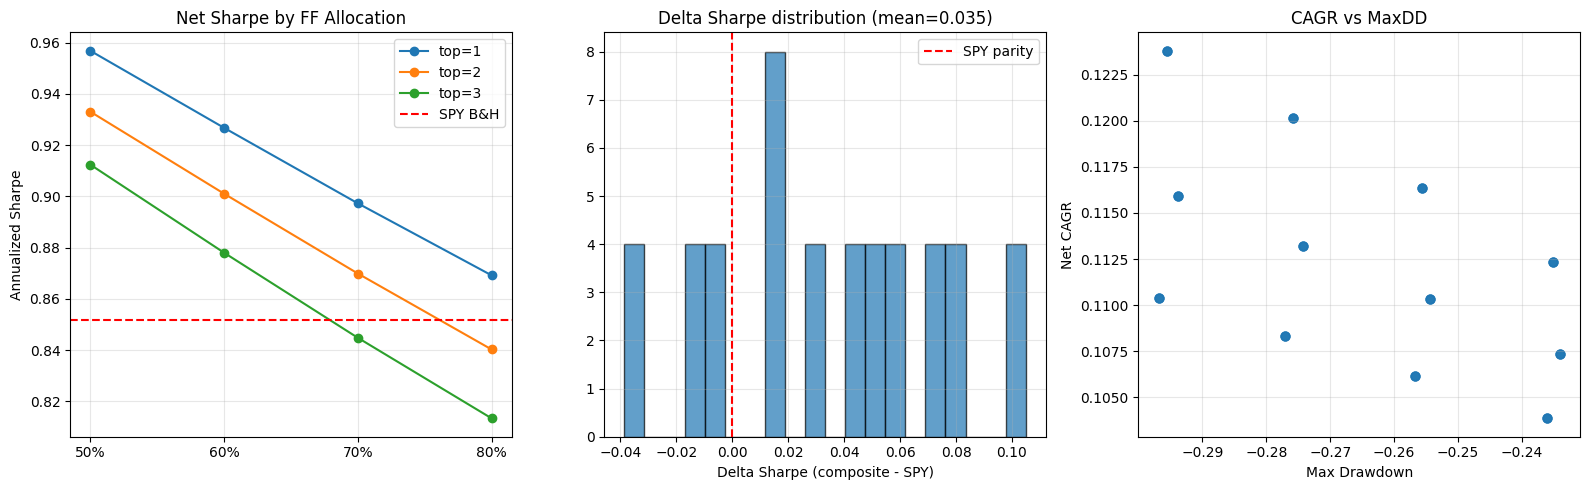

Figure saved: composite_ff_aw_results.png


In [7]:
import matplotlib.pyplot as plt

if rows:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # 1. Sharpe by allocation
    for top_n in TOP_N_VALUES:
        subset = [r for r in rows if r["top_n"] == top_n]
        if not subset:
            continue
        allocs = sorted(set(r["ff_alloc"] for r in subset))
        sharpes = [np.mean([r["sharpe_net"] for r in subset if r["ff_alloc"] == a]) for a in allocs]
        axes[0].plot([f"{a:.0%}" for a in allocs], sharpes, marker="o", label=f"top={top_n}")
    axes[0].axhline(y=rows[0]["sharpe_spy"], color="red", linestyle="--", label="SPY B&H")
    axes[0].set_title("Net Sharpe by FF Allocation")
    axes[0].set_ylabel("Annualized Sharpe")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Delta Sharpe distribution
    deltas = [r["sharpe_net"] - r["sharpe_spy"] for r in rows 
              if not np.isnan(r["sharpe_net"]) and not np.isnan(r["sharpe_spy"])]
    axes[1].hist(deltas, bins=20, edgecolor="black", alpha=0.7)
    axes[1].axvline(x=0, color="red", linestyle="--", label="SPY parity")
    axes[1].set_title(f"Delta Sharpe distribution (mean={np.mean(deltas):.3f})")
    axes[1].set_xlabel("Delta Sharpe (composite - SPY)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 3. CAGR vs MaxDD scatter
    cagrs = [r["cagr_net"] for r in rows if not np.isnan(r.get("cagr_net", np.nan))]
    mdds = [r["max_dd_net"] for r in rows if not np.isnan(r.get("max_dd_net", np.nan))]
    if cagrs and mdds:
        axes[2].scatter(mdds, cagrs, alpha=0.6, s=40)
        axes[2].set_xlabel("Max Drawdown")
        axes[2].set_ylabel("Net CAGR")
        axes[2].set_title("CAGR vs MaxDD")
        axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("composite_ff_aw_results.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("Figure saved: composite_ff_aw_results.png")
else:
    print("No data to plot")

## 7. Conclusion

Ce notebook reproduit l'architecture du Framework Composite TrendWeather avec les signaux FamaFrench (rotation factorielle) et AllWeather (socle defensif). Le sweep FF50-AW50 a FF80-AW20 avec top-1/2/3 facteurs et 4 seeds determine si la combinaison bat le SPY B&H.

**Hypotheses testees** :
1. La decorrelation facteur/macro du composite ameliore le Sharpe vs chaque composant seul
2. Un FF60-AW40 ou FF70-AW30 offre le meilleur compromis rendement/risque
3. Le momentum risque-ajuste est superieur au momentum brut pour la selection factorielle

**Baseline** : SPY Buy & Hold (Sharpe ~0.78-1.15 selon periode).